In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

from matplotlib.pyplot import figure
from astropy.io import fits
from astropy.table import Table

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import QTable
from astropy.table import Table

# 1. Find training data

Here, we will:

1. Import SDSS data, apply some filters

2. Import Gaia data (IDs + colors), apply some filters

3. Cross match between Gaia and SDSS to find training set

4. Separate giants and dwarfs

6. Save training set IDs to download their RVS spectra

7. Combine labels and fluxes in a dataframe and save it in a format ready to use for Lux

## Import SDSS data

Cuts on SDSS:

SNR > 200

e_fe_h > 0.1

e_mg_h > 0.1

We will apply temperature cuts later on, where we separate giants and dwarfs.

In [12]:
filename_path = '../../data/astraAllStarASPCAP-0.7.fits'

# this function is Lucy's way to get rid of columns that are more than 1D (pandas doesn't support that)
def Table_to_pandas(fn):
    data = fits.open(fn)
    df = QTable(data[2].data)
    cols = []
    cols_drop = []
    for i in df.columns:
        if np.size(df[i][0])==1:
            cols.append(i)
        else:
            cols_drop.append(i)
    print(cols_drop)
    return df[cols].to_pandas()

df_sdss5 = Table_to_pandas(filename_path)

['sdss5_target_flags']


In [13]:
#df_sdss5 = df_sdss5[(df_sdss5['teff']>4500) & (df_sdss5['teff']<6500)]
df_sdss5 = df_sdss5[(df_sdss5['snr']>=200)]

df_sdss5 = df_sdss5[df_sdss5['gaia_dr3_source_id'] > 0]
df_sdss5 = df_sdss5[(df_sdss5['e_fe_h'] < 0.1) & (df_sdss5['e_mg_h'] < 0.1)]

df_sdss5 = df_sdss5.sort_values(['snr'], ascending=False)
df_sdss5 = df_sdss5.drop_duplicates(subset='gaia_dr3_source_id', keep='first')

print("number of stars in SDSS = ", len(df_sdss5))

number of stars in SDSS =  163300


## Import Gaia data (IDs and colors)

Cut here is just SNR > 100. I used the following query to get all stars in Gaia with RVS spectra who have SNR > 100.

```sql
SELECT 
  source_id, ra, dec, parallax, pmra, pmdec, 
  radial_velocity, rvs_spec_sig_to_noise, 
  teff_gspphot, logg_gspphot, mh_gspphot,
  phot_g_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE has_rvs = 'True' 
  AND rvs_spec_sig_to_noise > 100

In [100]:
gaia_df = pd.read_csv("gaia_IDs_and_colors.csv")

print("number of stars in gaia = ", len(gaia_df))

number of stars in gaia =  120520


## Cross match between Gaia and SDSS

In [16]:
training_set = gaia_df.merge(df_sdss5, left_on='source_id', right_on='gaia_dr3_source_id', how='inner')

print("number of stars in both gaia and sdss so far = ", len(training_set))

number of stars in both gaia and sdss so far =  10233


Then, we will save IDs for the training set to download their spectra from Gaia AIP. 

I name this file "raw" because we haven't had any cuts on temperature yet, and haven't separated dwarfs and giants.

Side note: it will probably be more efficient to do those first and then download the spectra. But this is just how I felt more comfortable doing things.

In [20]:
training_set_table = Table.from_pandas(training_set[['source_id']])

training_set_table.write("training_set_IDs_raw.vot", format="votable", overwrite=True)

This is the query I used:

Replace "ID_list_name" with the name of the VOT table you upload at Gaia AIP.

```sql
SELECT rvs.*

FROM "gaiadr3"."rvs_mean_spectrum" AS rvs

JOIN "gaia_user_htajer"."ID_list_name" AS mytargets ON mytargets."source_id" = rvs.source_id

In [22]:
# Wavelengths for the spectra
lambdas = np.linspace(846, 870, 2401)
t = Table.read("training_set_RVS_raw.xml", format="votable")
training_rvs_df = t.to_pandas()
training_rvs_df['source_id'] = training_rvs_df['datalinkID']
training_rvs_df = training_rvs_df[['source_id', 'flux', 'flux_error']]

Now let's just take a look at one of them:

Text(0, 0.5, 'Flux')

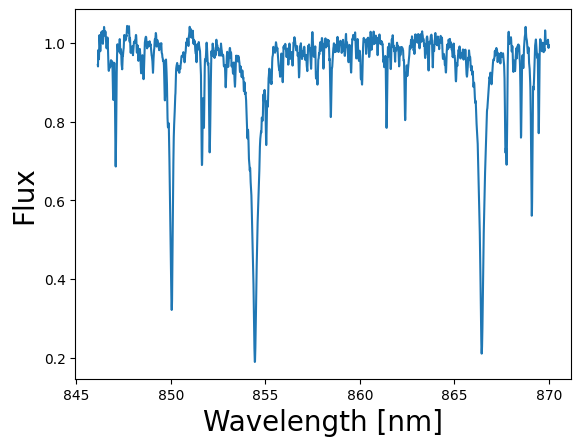

In [23]:
eg_giant = training_rvs_df.iloc[0]

plt.plot(lambdas, eg_giant['flux'])
plt.xlabel('Wavelength [nm]', fontsize=20)
plt.ylabel('Flux', fontsize=20)

In [24]:
training_rvs_df.head()

,source_id,flux,flux_error
0,458501232174305920,"[--, --, --, --, --, --, --, --, --, --, --, -...","[--, --, --, --, --, --, --, --, --, --, --, -..."
1,505676671912111488,"[0.9713414, 0.97205245, 0.96980894, 0.9704494,...","[0.005380153, 0.00503135, 0.005139816, 0.00572..."
2,513104628875298176,"[--, --, --, --, --, --, --, --, --, --, --, -...","[--, --, --, --, --, --, --, --, --, --, --, -..."
3,513445408752620928,"[--, --, --, --, --, --, --, --, --, --, 0.963...","[--, --, --, --, --, --, --, --, --, --, 0.033..."
4,515604123736656000,"[0.96674216, 0.96871907, 0.9699684, 0.9732878,...","[0.007674468, 0.008523305, 0.009207881, 0.0089..."


Merge `training_set` with `training_rvs_df` to have everything in the same dataframe.

In [30]:
training_set = training_set.merge(training_rvs_df, on='source_id', how='inner')

Next, we need to divide the training set into dwarfs and giants, and choose labels for each.

In [25]:
# For giants and dwarfs
most_reliable_giants = ['c_h', 'n_h', 'o_h', 'mg_h', 'al_h', 'si_h', 'mn_h', 'fe_h', 'ni_h']
reliable_giants = ['na_h', 'k_h', 'ca_h', 'co_h', 'ce_h']
most_reliable_dwarfs = ['c_h', 'mg_h', 'si_h', 'fe_h', 'ni_h']
reliable_dwarfs = ['o_h', 'al_h', 'k_h', 'ca_h', 'mn_h']

gaia_elements = ['n_h', 'mg_h', 'si_h', 's_h', 'ca_h', 'ti_h', 'cr_h', 'fe_h', 'ni_h', 'ce_h', 'nd_h']

giant_elements = [] #most_reliable + reliable
dwarf_elements = [] #most_reliable + reliable

print("*** Gaia elements in most reliable + reliable giants: ***")
for i in range(len(most_reliable_giants)):
    if most_reliable_giants[i] in gaia_elements:
        giant_elements.append(most_reliable_giants[i])

for i in range(len(reliable_giants)):
    if reliable_giants[i] in gaia_elements:
        giant_elements.append(reliable_giants[i])

print(giant_elements)

print("*** Gaia elements in most reliable + reliable dwarfs: ***")
for i in range(len(most_reliable_dwarfs)):
    if most_reliable_dwarfs[i] in gaia_elements:
        dwarf_elements.append(most_reliable_dwarfs[i])

for i in range(len(reliable_dwarfs)):
    if reliable_dwarfs[i] in gaia_elements:
        dwarf_elements.append(reliable_dwarfs[i])
    
print(dwarf_elements)

*** Gaia elements in most reliable + reliable giants: ***
['n_h', 'mg_h', 'si_h', 'fe_h', 'ni_h', 'ca_h', 'ce_h']
*** Gaia elements in most reliable + reliable dwarfs: ***
['mg_h', 'si_h', 'fe_h', 'ni_h', 'ca_h']


Make cuts to find giants, and save everything clean and ready to use for Lux.

1. Select logg between 1.5 and 3.5

2. Select teff < 6500 (get rid of very hot ones) but no temperature cut needed for cool stars 

3. Select ones with low errors on metallicities in all elements used for giants

In [32]:
giants_label_names = ['source_id', 'teff', 'e_teff', 'logg', 'e_logg']
giants_label_names += [
    col
    for el in giant_elements
    for col in (el, f"e_{el}")
]

training_giants = training_set[(training_set['logg'] > 1.5) & (training_set['logg'] < 3.5)]
training_giants = training_giants[(training_giants['teff'] < 6500)]

training_giants = training_giants[training_giants['e_fe_h'] < 0.1]
training_giants = training_giants[training_giants['e_mg_h'] < 0.1]
training_giants = training_giants[training_giants['e_si_h'] < 0.1]
training_giants = training_giants[training_giants['e_ni_h'] < 0.1]
training_giants = training_giants[training_giants['e_ca_h'] < 0.1]
training_giants = training_giants[training_giants['e_ce_h'] < 0.1]

print("number of giants left in the training set = ", len(training_giants))

number of giants left in the training set =  6092


Make it ready to use for Lux and save in a pkl file.

In [ ]:
for p in ['teff', 'logg', 'n_h', 'mg_h', 'si_h', 'fe_h', 'ni_h', 'ca_h', 'ce_h']:
    err_col = f"e_{p}"
    # Boolean mask of missing values (NaN)
    mask = training_giants[p].isna() | training_giants[p].astype(str).isin(['--', 'masked', '<Masked>']) | training_giants[err_col].isna() | training_giants[err_col].astype(str).isin(['--', 'masked', '<Masked>'])
    stars_masked = training_giants[~mask]
    med = np.median(stars_masked[p])
    training_giants.loc[mask, p] = med
    training_giants.loc[mask, err_col] = 9999

#training_giants.to_pickle('training_set_giants.pkl')

Now the same thing for dwarfs:

1. Select logg > 3.5

2. Select teff < 6500 (get rid of very hot ones) and also get rid of cool ones (teff > 4500)

3. Select ones with low errors on metallicities in all elements used for dwarfs


In [34]:
dwarfs_label_names = ['source_id', 'teff', 'e_teff', 'logg', 'e_logg']
dwarfs_label_names += [
    col
    for el in giant_elements
    for col in (el, f"e_{el}")
]

training_dwarfs = training_set[(training_set['logg'] > 3.5)]
training_dwarfs = training_dwarfs[(training_dwarfs['teff'] < 6500) & (training_dwarfs['teff'] > 4500)]

training_dwarfs = training_dwarfs[training_dwarfs['e_fe_h'] < 0.1]
training_dwarfs = training_dwarfs[training_dwarfs['e_mg_h'] < 0.1]
training_dwarfs = training_dwarfs[training_dwarfs['e_si_h'] < 0.1]
training_dwarfs = training_dwarfs[training_dwarfs['e_ni_h'] < 0.1]
training_dwarfs = training_dwarfs[training_dwarfs['e_ca_h'] < 0.1]

print("number of dwarfs left in the training set = ", len(training_dwarfs))

number of dwarfs left in the training set =  2392


In [ ]:
for p in ['teff', 'logg', 'n_h', 'mg_h', 'si_h', 'fe_h', 'ni_h', 'ca_h']:
    err_col = f"e_{p}"
    # Boolean mask of missing values (NaN)
    mask = training_dwarfs[p].isna() | training_dwarfs[p].astype(str).isin(['--', 'masked', '<Masked>']) | training_dwarfs[err_col].isna() | training_dwarfs[err_col].astype(str).isin(['--', 'masked', '<Masked>'])
    stars_masked = training_dwarfs[~mask]
    med = np.median(stars_masked[p])
    training_dwarfs.loc[mask, p] = med
    training_dwarfs.loc[mask, err_col] = 9999

#training_dwarfs.to_pickle('training_set_dwarfs.pkl')

# 2. Find test data

1. Apply KDtest to only include stars in the test set who are represented well by the training set

2. Save IDs of those stars (test set)

3. Get RVS spectra for test set

4. Tidy up the data to be ready to use with Lux

As a reminder, `gaia_df` is the dataframe that has Gaia IDs and colors for all stars with RVS spectra with SNR > 100.

`training_giants` is the training set for giants and `training_dwarfs` is the training set for dwarfs.

In the end, we want to have a dataframe called `test_giants` and `test_dwarfs`. Test set doesn't need to have labels. 

To find the test set, we match the color magnitude diagrams of the test set and the training set, and exclude stars that are not represented in the training set.

# Plot the color magnitude diagram

We need to convert g_mean_mag to absolute magnitude:

abs_mag = phot_g_mean_mag+5 + log10(parallax/100)

In [40]:
def get_M(m, parallax):
    M = m - 5 * np.log10(1000/parallax) + 5
    return M

gaia_df['M'] = get_M(m = gaia_df['phot_g_mean_mag'], parallax=gaia_df['parallax'])
gaia_df['g-rp'] = gaia_df['phot_g_mean_mag'] - gaia_df['phot_rp_mean_mag']

training_giants['M'] = get_M(m=training_giants['phot_g_mean_mag'], parallax=training_giants['parallax'])
training_giants['g-rp'] = training_giants['phot_g_mean_mag'] - training_giants['phot_rp_mean_mag']

training_dwarfs['M'] = get_M(m=training_dwarfs['phot_g_mean_mag'], parallax=training_dwarfs['parallax'])
training_dwarfs['g-rp'] = training_dwarfs['phot_g_mean_mag'] - training_dwarfs['phot_rp_mean_mag']

/Users/honeyeah/miniconda3/envs/haniyeh_research/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


We can divide all gaia stars in `gaia_df` into giants and dwarfs as well.

In [56]:
giants_gaia_all = gaia_df[(gaia_df['logg_gspphot'] < 3.5) & (gaia_df['logg_gspphot'] > 1.5)]
dwarfs_gaia_all = gaia_df[(gaia_df['logg_gspphot'] > 3.5)]

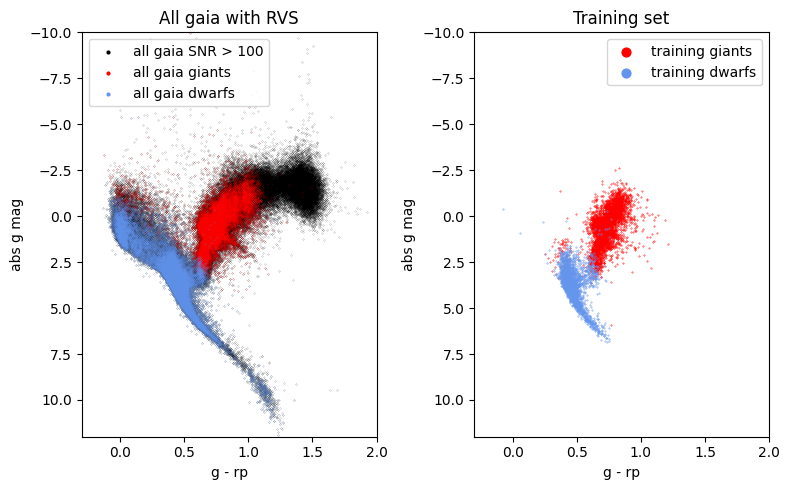

In [60]:
color_giants = 'red'
color_dwarfs = 'cornflowerblue'

plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.title("All gaia with RVS")
plt.scatter(gaia_df['g-rp'], gaia_df['M'], s = 0.01, label = 'all gaia SNR > 100', color = 'black')
plt.scatter(giants_gaia_all['g-rp'], giants_gaia_all['M'], s = 0.01, label = 'all gaia giants', color = color_giants)
plt.scatter(dwarfs_gaia_all['g-rp'], dwarfs_gaia_all['M'], s = 0.01, label = 'all gaia dwarfs', color = color_dwarfs)
plt.legend(markerscale=20)
plt.xlabel("g - rp")
plt.ylabel("abs g mag")
plt.ylim(-10, 12)
plt.xlim(-0.3,2)
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
plt.title("Training set")
plt.scatter(training_giants['g-rp'], training_giants['M'] ,s = 0.1, label = 'training giants', color = color_giants)
plt.scatter(training_dwarfs['g-rp'], training_dwarfs['M'] ,s = 0.1, label = 'training dwarfs', color = color_dwarfs)
plt.xlabel("g - rp")
plt.legend(markerscale=20)
plt.ylabel("abs g mag")
plt.ylim(-10, 12)
plt.xlim(-0.3,2)
plt.gca().invert_yaxis()


plt.tight_layout()

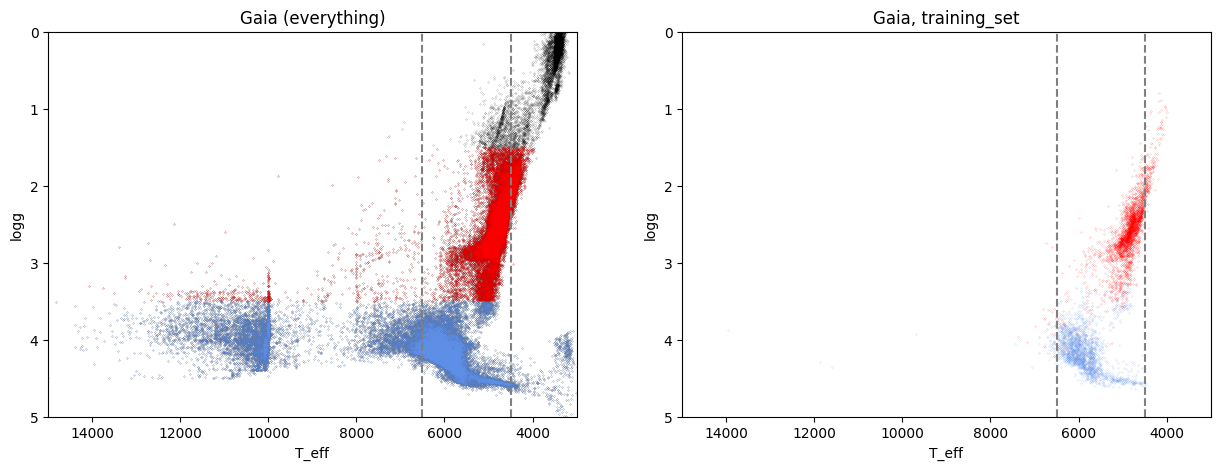

In [63]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.title("Gaia (everything)")
plt.scatter(gaia_df['teff_gspphot'], gaia_df['logg_gspphot'], s = 0.01, color = 'black', label = 'all gaia SNR > 100')
plt.scatter(giants_gaia_all['teff_gspphot'], giants_gaia_all['logg_gspphot'], s = 0.01,
            color = color_giants, label = 'all gaia giants')
plt.scatter(dwarfs_gaia_all['teff_gspphot'], dwarfs_gaia_all['logg_gspphot'], s = 0.01,
            color = color_dwarfs, label = 'all gaia dwarfs')
plt.xlim(3000,15000)
plt.xlabel("T_eff")
plt.ylabel("logg")
plt.ylim(0,5)
plt.axvline(4500, linestyle='--', color = 'gray')
plt.axvline(6500, linestyle='--', color = 'gray')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.subplot(1,2,2)
plt.title("Gaia, training_set")
plt.scatter(training_giants['teff_gspphot'], training_giants['logg_gspphot'], s = 0.01, color = color_giants)
plt.scatter(training_dwarfs['teff_gspphot'], training_dwarfs['logg_gspphot'], s = 0.01, color = color_dwarfs)
plt.xlim(3000,15000)
plt.ylim(0,5)
plt.xlabel("T_eff")
plt.ylabel("logg")
plt.axvline(4500, linestyle='--', color = 'gray')
plt.axvline(6500, linestyle='--', color = 'gray')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

In [64]:
print("number of giants in all gaia before KDTest = ", len(giants_gaia_all))
print("number of dwarfs in all gaia before KDTest = ", len(dwarfs_gaia_all))

number of giants in all gaia before KDTest =  27004
number of dwarfs in all gaia before KDTest =  25905


Now we do the KDTest to only keep stars in the test set who are represented with the training set. 

Disclaimer: I used AI to do this. We might need to double check!

First for giants:

In [82]:
# Giants

from scipy.spatial import cKDTree

# 1. Isolate the numeric columns (ignores the array columns like 'flux')
num_cols = training_giants.select_dtypes(include='number').columns

# 2. Replace infinities only in those columns, then drop the NaNs
training_giants_clean = training_giants.copy()
training_giants_clean[num_cols] = training_giants_clean[num_cols].replace([np.inf, -np.inf], np.nan)
training_giants_clean = training_giants_clean.dropna(subset=['M', 'g-rp'])

test_clean_g = giants_gaia_all.replace([np.inf, -np.inf], np.nan).dropna(subset=['M', 'g-rp'])

# 3. Extract and stack your 2D parameters from the clean data
train_data_giants = np.column_stack((training_giants_clean['M'], training_giants_clean['g-rp']))
test_data_giants = np.column_stack((test_clean_g['M'], test_clean_g['g-rp']))

# 4. Build the KDTree and query
tree = cKDTree(train_data_giants)
distances, _ = tree.query(test_data_giants)

# 5. Filter the test set
threshold = 0.01 
valid_mask = distances < threshold

# Apply mask directly to the cleaned DataFrame to keep all original columns
KDTest_giants = test_clean_g[valid_mask]

In [83]:
# Dwarfs

# 1. Isolate the numeric columns (ignores the array columns like 'flux')
num_cols = training_dwarfs.select_dtypes(include='number').columns

# 2. Replace infinities only in those columns, then drop the NaNs
training_dwarfs_clean = training_dwarfs.copy()
training_dwarfs_clean[num_cols] = training_dwarfs_clean[num_cols].replace([np.inf, -np.inf], np.nan)
training_dwarfs_clean = training_dwarfs_clean.dropna(subset=['M', 'g-rp'])

test_clean_d = dwarfs_gaia_all.replace([np.inf, -np.inf], np.nan).dropna(subset=['M', 'g-rp'])

# 3. Extract and stack your 2D parameters from the clean data
train_data_dwarfs = np.column_stack((training_dwarfs_clean['M'], training_dwarfs_clean['g-rp']))
test_data_dwarfs = np.column_stack((test_clean_d['M'], test_clean_d['g-rp']))

# 4. Build the KDTree and query
tree = cKDTree(train_data_dwarfs)
distances, _ = tree.query(test_data_dwarfs)

# 5. Filter the test set
threshold = 0.01 
valid_mask = distances < threshold

# Apply mask directly to the cleaned DataFrame to keep all original columns
KDTest_dwarfs = test_clean_d[valid_mask]

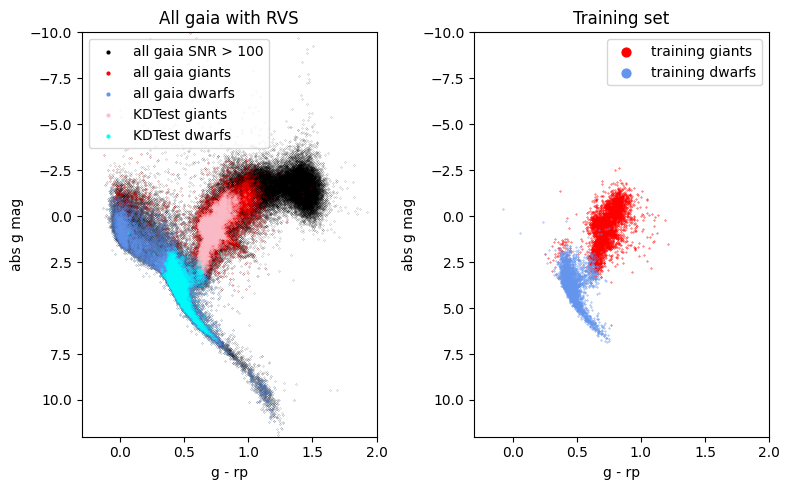

In [87]:
color_KDTest_giants = 'pink'
color_KDTest_dwarfs = 'cyan'

plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.title("All gaia with RVS")
plt.scatter(gaia_df['g-rp'], gaia_df['M'], s = 0.01, label = 'all gaia SNR > 100', color = 'black')
plt.scatter(giants_gaia_all['g-rp'], giants_gaia_all['M'], s = 0.01, label = 'all gaia giants', color = color_giants)
plt.scatter(dwarfs_gaia_all['g-rp'], dwarfs_gaia_all['M'], s = 0.01, label = 'all gaia dwarfs', color = color_dwarfs)

plt.scatter(KDTest_giants['g-rp'], KDTest_giants['M'], s = 0.01, label = 'KDTest giants', color = color_KDTest_giants)
plt.scatter(KDTest_dwarfs['g-rp'], KDTest_dwarfs['M'], s = 0.01, label = 'KDTest dwarfs', color = color_KDTest_dwarfs)

plt.legend(markerscale=20)
plt.xlabel("g - rp")
plt.ylabel("abs g mag")
plt.ylim(-10, 12)
plt.xlim(-0.3,2)
plt.gca().invert_yaxis()

plt.subplot(1,2,2)
plt.title("Training set")
plt.scatter(training_giants['g-rp'], training_giants['M'] ,s = 0.1, label = 'training giants', color = color_giants)
plt.scatter(training_dwarfs['g-rp'], training_dwarfs['M'] ,s = 0.1, label = 'training dwarfs', color = color_dwarfs)
plt.xlabel("g - rp")
plt.legend(markerscale=20)
plt.ylabel("abs g mag")
plt.ylim(-10, 12)
plt.xlim(-0.3,2)
plt.gca().invert_yaxis()


plt.tight_layout()

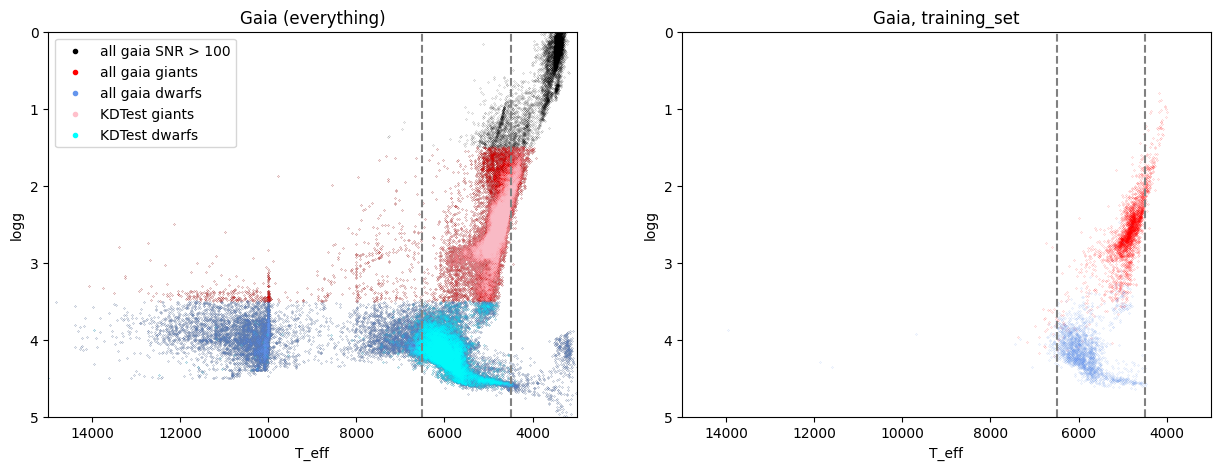

In [91]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.title("Gaia (everything)")
plt.scatter(gaia_df['teff_gspphot'], gaia_df['logg_gspphot'], s = 0.01, color = 'black', label = 'all gaia SNR > 100')
plt.scatter(giants_gaia_all['teff_gspphot'], giants_gaia_all['logg_gspphot'], s = 0.01,
            color = color_giants, label = 'all gaia giants')
plt.scatter(dwarfs_gaia_all['teff_gspphot'], dwarfs_gaia_all['logg_gspphot'], s = 0.01,
            color = color_dwarfs, label = 'all gaia dwarfs')

plt.scatter(KDTest_giants['teff_gspphot'], KDTest_giants['logg_gspphot'], s = 0.01,
            color = color_KDTest_giants, label = 'KDTest giants')
plt.scatter(KDTest_dwarfs['teff_gspphot'], KDTest_dwarfs['logg_gspphot'], s = 0.01,
            color = color_KDTest_dwarfs, label = 'KDTest dwarfs')
plt.legend(markerscale=30)

plt.xlim(3000,15000)
plt.xlabel("T_eff")
plt.ylabel("logg")
plt.ylim(0,5)
plt.axvline(4500, linestyle='--', color = 'gray')
plt.axvline(6500, linestyle='--', color = 'gray')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.subplot(1,2,2)
plt.title("Gaia, training_set")
plt.scatter(training_giants['teff_gspphot'], training_giants['logg_gspphot'], s = 0.01, color = color_giants)
plt.scatter(training_dwarfs['teff_gspphot'], training_dwarfs['logg_gspphot'], s = 0.01, color = color_dwarfs)
plt.xlim(3000,15000)
plt.ylim(0,5)
plt.xlabel("T_eff")
plt.ylabel("logg")
plt.axvline(4500, linestyle='--', color = 'gray')
plt.axvline(6500, linestyle='--', color = 'gray')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

In [92]:
KDTest_giants.to_csv("gaia_giants_filtered_KDTree.csv", index=False)
KDTest_dwarfs.to_csv("gaia_dwarfs_filtered_KDTree.csv", index=False)

Save the test set IDs to submit the query on Gaia AIP.

In [93]:
print("Number of test set giants after KDTest = ", len(KDTest_giants))
print("Number of test set dwarfs after KDTest = ", len(KDTest_dwarfs))

Number of test set giants after KDTest =  19627
Number of test set dwarfs after KDTest =  12472


In [94]:
# Convert the DataFrames to Astropy Tables (keeping the SOURCE_ID column name)
giants_table = Table.from_pandas(KDTest_giants[['source_id']])
dwarfs_table = Table.from_pandas(KDTest_dwarfs[['source_id']])

# Save them as VOTable files
giants_table.write("KDTree_filtered_giants_IDs.vot", format="votable", overwrite=True)
dwarfs_table.write("KDTree_filtered_dwarfs_IDs.vot", format="votable", overwrite=True)

Now we submit a query to get the RVS for test set giants and test set dwarfs.

Replace "KDTree_giants_2" with the name of the VOT table you upload at Gaia AIP.

```sql
SELECT rvs.*

FROM "gaiadr3"."rvs_mean_spectrum" AS rvs

JOIN "gaia_user_htajer"."KDTree_filtered_giants_IDs" AS mytargets ON mytargets."source_id" = rvs.source_id

Make them ready to use for Lux and save them in a pkl file.

In [96]:
lambdas = np.linspace(846, 870, 2401)

t_giants_test = Table.read("test_giants_RVS.xml", format="votable")
t_dwarfs_test = Table.read("test_dwarfs_RVS.xml", format="votable")

test_rvs_giants = t_giants_test.to_pandas()
test_rvs_dwarfs = t_dwarfs_test.to_pandas()

Text(0, 0.5, 'Flux')

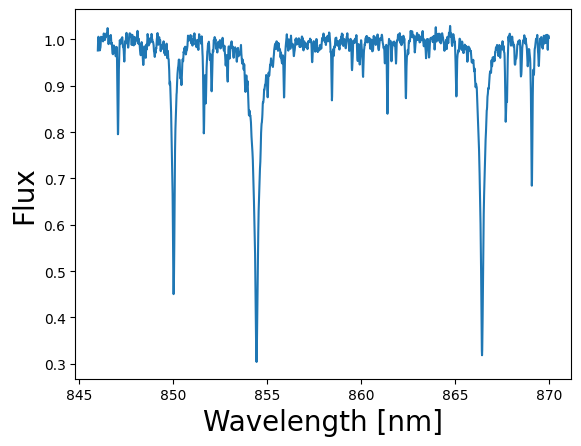

In [97]:
eg_giant = test_rvs_giants.iloc[0]

plt.plot(lambdas, eg_giant['flux'])
plt.xlabel('Wavelength [nm]', fontsize=20)
plt.ylabel('Flux', fontsize=20)

In [98]:
test_rvs_giants_flux = test_rvs_giants[['datalinkID', 'flux', 'flux_error']].copy()
test_rvs_giants_flux['source_id'] = test_rvs_giants_flux['datalinkID']
test_rvs_giants_flux.head()

test_rvs_dwarfs_flux = test_rvs_dwarfs[['datalinkID', 'flux', 'flux_error']].copy()
test_rvs_dwarfs_flux['source_id'] = test_rvs_dwarfs_flux['datalinkID']
test_rvs_dwarfs_flux.head()

,datalinkID,flux,flux_error,source_id
0,514005609922766336,"[0.9890444, 0.98159564, 0.9802874, 0.98064333,...","[0.007106618, 0.0066702426, 0.006986153, 0.007...",514005609922766336
1,464474363446935808,"[--, --, --, --, --, --, --, 0.95677775, 0.994...","[--, --, --, --, --, --, --, 0.06557224, 0.026...",464474363446935808
2,464554696516584960,"[--, --, --, --, --, --, --, --, --, --, --, -...","[--, --, --, --, --, --, --, --, --, --, --, -...",464554696516584960
3,464654614636219392,"[--, --, --, --, --, --, --, 0.9982544, 0.9937...","[--, --, --, --, --, --, --, 0.005395444, 0.00...",464654614636219392
4,464862765927212416,"[--, --, --, --, --, --, --, --, --, 0.9756777...","[--, --, --, --, --, --, --, --, --, 0.0087709...",464862765927212416


In [99]:
test_rvs_giants_flux.to_pickle('test_set_KDTree_giants_rvs_fluxes.pkl')
test_rvs_dwarfs_flux.to_pickle('test_set_KDTree_dwarfs_rvs_fluxes.pkl')